# 12-QLoRA & Sub-Byte Mathematics

In Lesson 11, we solved the gradient tracking problem. By using **LoRA**, we reduced the *trainable* parameters of a 70-Billion parameter model from 70B down to just a few million.

However, a fatal physics problem remains: **The Frozen Base Model**.
Even if we are not updating the 70 Billion weights, we still have to load them into the GPU's VRAM just to perform the Forward Pass. In standard 16-bit precision (`bfloat16`), a 70B model physically weighs **140 Gigabytes**. A standard consumer GPU (like an RTX 4090) only has 24 GB of VRAM. It cannot even load $20\%$ of the model.

In 2023, Tim Dettmers and researchers at the University of Washington published **QLoRA** (Quantized Low-Rank Adaptation). They discovered how to mathematically crush a Foundation Model down to **4 bits per parameter** without losing its cognitive abilities, allowing massive enterprise models to be fine-tuned on a single consumer graphics card.

Let's set up our PyTorch environment to deconstruct the mathematics of Information Theory and Sub-Byte Compression.


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch QLoRA & Sub-Byte Mathematics Environment Ready.")

✅ PyTorch QLoRA & Sub-Byte Mathematics Environment Ready.


# 1. The 4-Bit Physics Limit

In Lesson 20 of our Computer Vision series, we explored standard `INT8` quantization. An 8-bit integer gives us $2^8 = 256$ discrete bins. This is plenty of resolution to approximate floating-point numbers.

But QLoRA compresses weights to **4 bits**. A 4-bit integer only has $2^4 = 16$ discrete bins.

If we use standard linear quantization (spacing the 16 bins equally), we instantly destroy the Neural Network. Why? Because the pre-trained weights of a Transformer are not uniformly distributed; they form a perfect **Bell Curve (Normal Distribution)** centered around $0.0$.

* If we space the 16 bins equally between $-1.0$ and $+1.0$, the extreme bins (like $-0.9$) will be completely empty because weights rarely get that large.
* Meanwhile, the dense cluster of thousands of weights near $0.0$ will be violently crushed into just 1 or 2 middle bins. The model becomes lobotomized.

# 2. 4-Bit NormalFloat (NF4)

To solve the distribution collapse, Dettmers invented a brand new mathematical data type specifically for Neural Networks: **The 4-Bit NormalFloat (NF4)**.

Instead of spacing the 16 bins equally across the *distance* of the values, NF4 uses **Quantile Quantization**. It mathematically maps the bins so that an *equal number of weights* falls into every single bin.

* The bins are densely packed together right at $0.0$ (where most of the weights live) to retain ultra-high precision.
* The bins are spread wide apart at the tails (where weights are rare).

This mathematical mapping guarantees the absolute minimum Information Loss possible when compressing a Gaussian distribution into 16 discrete states.

# 3. Double Quantization

When we quantize a block of weights (e.g., 64 weights), we must store a 32-bit Floating Point scaling constant ($c$) to remember how to "un-quantize" them later.
For a 70-Billion parameter model, storing one 32-bit constant for every 64 weights requires **hundreds of Megabytes** of pure metadata.

QLoRA introduces **Double Quantization**. We take the quantization constants ($c_1$) and we *quantize the constants themselves* into 8-bit integers using a second constant ($c_2$).


$$W^{FP16} \approx (c_2^{FP32} \times c_1^{FP8}) \times W^{NF4}$$


This incredibly aggressive mathematical recursion saves an average of **0.37 bits per parameter**, which translates to 3 Gigabytes of saved VRAM on a 70B model!

# 4. The QLoRA Architecture

The final QLoRA engine is an architectural masterpiece of mixed precision:

1. **The Base Model**: Loaded entirely in ultra-compressed **4-bit NF4**. It is frozen.
2. **The LoRA Adapters**: Injected alongside the base model. Because they are tiny, they are kept in pure, high-precision **16-bit (`bfloat16`)**.
3. **The Forward Pass**: When data $X$ hits a layer, the 4-bit NF4 weights are instantaneously dequantized back into 16-bit inside the GPU's ultra-fast L1 cache. The matrix math is executed in 16-bit, and the result is combined with the high-precision 16-bit LoRA adapter.

$$Y = X W^{NF4}_{dequantized} + X (B A)$$

# 5. Visualizing NF4 vs. Standard INT4 in PyTorch

Let's simulate the physics of quantizing a Transformer weight matrix. We will generate a Gaussian distribution of weights, calculate the exact bin edges for Standard INT4 versus NormalFloat4, and visually prove why NF4 saves the neural network from collapse.

--- 🧠 Simulating 4-Bit Compression on 100,000 Weights ---


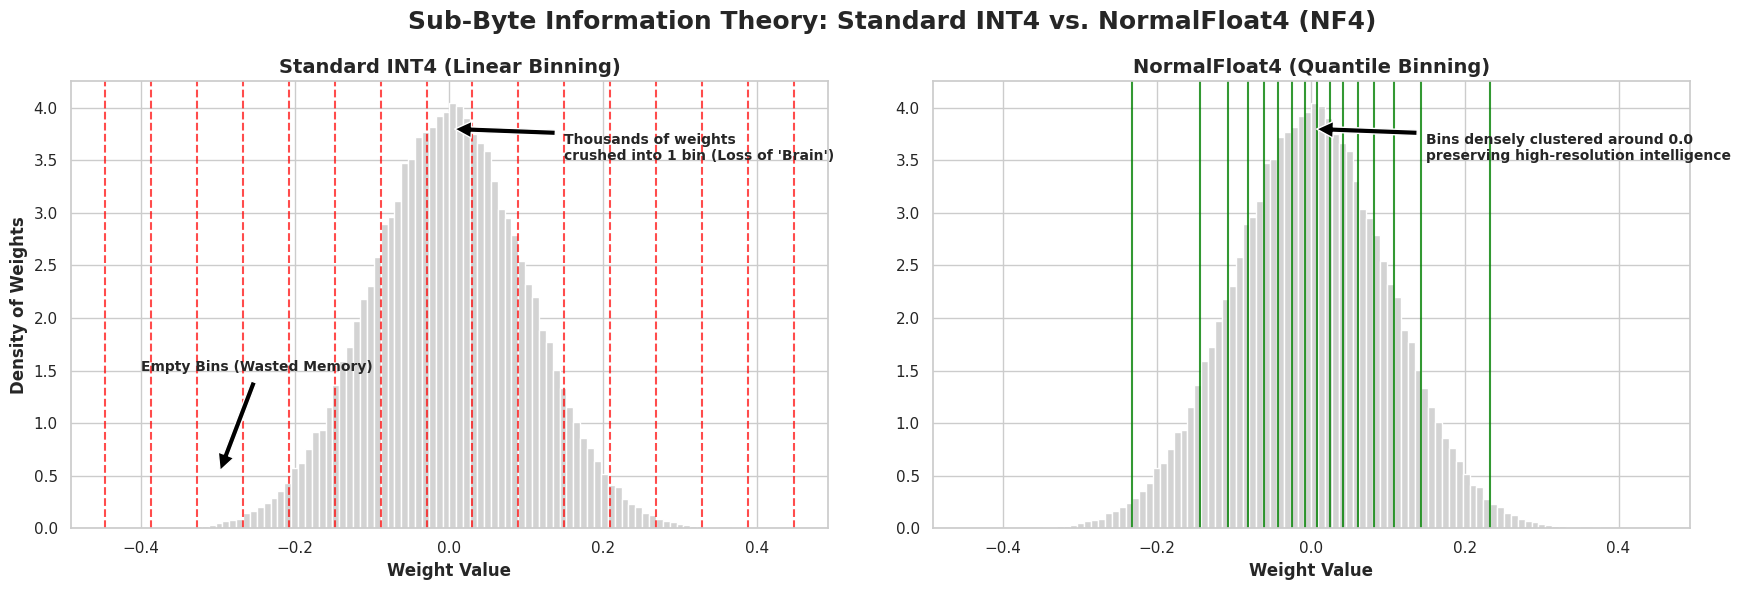


--- 🧮 VRAM Economics for Llama-3 70B ---
FP16 VRAM Requirement:  130.39 GB (Requires an $80,000 server rack)
NF4 VRAM Requirement:   32.60 GB (Fits on a single, consumer-grade GPU!)


In [2]:
# 1. Simulate the Transformer Weight Distribution (Gaussian / Bell Curve)
np.random.seed(42)
num_weights = 100000
# Weights are normally distributed around 0 with a small standard deviation
weights = np.random.normal(loc=0.0, scale=0.1, size=num_weights) 

print(f"--- 🧠 Simulating 4-Bit Compression on {num_weights:,} Weights ---")

# 2. Standard Linear 4-Bit (INT4)
# 16 bins spaced perfectly evenly between the min and max weight
min_w, max_w = np.min(weights), np.max(weights)
linear_bins = np.linspace(min_w, max_w, 16)

# 3. NormalFloat 4-Bit (NF4) Quantile Bins
# 16 bins spaced so that an equal percentile of data falls into each bin
# We use the inverse cumulative distribution function (PPF) of the standard normal
percentiles = np.linspace(0.01, 0.99, 16) 
nf4_bins = norm.ppf(percentiles, loc=0.0, scale=0.1)

# 4. Visualizing the Mathematical Topography
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Sub-Byte Information Theory: Standard INT4 vs. NormalFloat4 (NF4)", fontsize=18, fontweight='bold')

# Plot A: Standard INT4
axes[0].hist(weights, bins=100, color='lightgray', density=True)
# Overlay the 16 Linear Bins
for bin_edge in linear_bins:
    axes[0].axvline(bin_edge, color='red', linestyle='--', alpha=0.7)
axes[0].set_title("Standard INT4 (Linear Binning)", fontweight='bold', fontsize=14)
axes[0].set_xlabel("Weight Value", fontweight='bold')
axes[0].set_ylabel("Density of Weights", fontweight='bold')
axes[0].annotate("Empty Bins (Wasted Memory)", xy=(-0.3, 0.5), xytext=(-0.4, 1.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, fontweight='bold')
axes[0].annotate("Thousands of weights\ncrushed into 1 bin (Loss of 'Brain')", xy=(0.0, 3.8), xytext=(0.15, 3.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, fontweight='bold')

# Plot B: NormalFloat 4 (NF4)
axes[1].hist(weights, bins=100, color='lightgray', density=True)
# Overlay the 16 NF4 Bins
for bin_edge in nf4_bins:
    axes[1].axvline(bin_edge, color='green', linestyle='-', alpha=0.8)
axes[1].set_title("NormalFloat4 (Quantile Binning)", fontweight='bold', fontsize=14)
axes[1].set_xlabel("Weight Value", fontweight='bold')
axes[1].annotate("Bins densely clustered around 0.0\npreserving high-resolution intelligence", xy=(0.0, 3.8), xytext=(0.15, 3.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Calculating the VRAM Economics
print("\n--- 🧮 VRAM Economics for Llama-3 70B ---")
params_70b = 70 * (10**9)

# 16-bit (2 bytes per parameter)
fp16_gb = (params_70b * 2) / (1024**3)
# 4-bit (0.5 bytes per parameter)
nf4_gb = (params_70b * 0.5) / (1024**3)

print(f"FP16 VRAM Requirement:  {fp16_gb:.2f} GB (Requires an $80,000 server rack)")
print(f"NF4 VRAM Requirement:   {nf4_gb:.2f} GB (Fits on a single, consumer-grade GPU!)")

## Real-World Use Case or Analogy:

Think of QLoRA like **Transporting an entire Symphony Orchestra in a single Minivan**:

* **Standard FP16 Training**: You rent a massive 18-wheeler truck (an 8-GPU Server Node). You carefully pack all 100 musicians and their instruments inside. It is incredibly expensive, and only massive corporations can afford to move the orchestra.
* **Standard INT4 (Linear Binning)**: You try to force the 100 musicians into a Honda Civic. You just chop the car into 16 equal-sized squares. Because a tuba is huge and a flute is tiny, 10 flute players are crushed into a single square and suffocate, while the square meant for the tuba's mouthpiece is completely empty. The orchestra dies.
* **NormalFloat4 (NF4)**: You are a structural engineering genius. You custom-mold the interior of the Honda Civic to exactly match the specific body shape of the orchestra (Quantile Mapping). The tiny flute players get tightly packed, highly efficient custom seats in the center, and the big tuba players get wide, sparse seats in the back.
* **The LoRA Adapter**: The orchestra is perfectly preserved in the minivan (Frozen 4-bit Base), but they cannot change their sheet music while packed so tightly. So, you add a high-precision, flexible walkie-talkie to the dashboard (The 16-bit Trainable LoRA). You can teach the frozen orchestra brand new songs through the radio!